##### Integrating segments into your predictive modeling

In [60]:
# Step 1: Generate Segments & Attach to Main Dataset

from segmentation import fit_segmenter, predict_cluster

# Fit the segmenter on your cleaned features
segmenter, reducer, cluster_labels = fit_segmenter(X_clean, n_clusters=3)

# Add the segment labels to your raw data (this is useful for analysis or modeling)
X_raw["segment"] = cluster_labels


✅ Silhouette Score: 0.143


In [61]:
# Step 2: Add Segment as a Feature to Modeling Pipeline

# Convert cluster labels to string to treat them as categorical
X_raw["segment"] = X_raw["segment"].astype(str)

# Add 'segment' to your categorical columns
cat_col.append("segment")


In [62]:
X_clean = preproc.fit_transform(X_raw)


## Predictive Modelling

TASK 1
Step 1: Start with data cleaning and splitting.

Step 2: Experiment with different models (Logistic Regression, Random Forest, etc.).

Step 3: Evaluate the model using metrics and visualizations.

Step 4: Try hyperparameter tuning to improve performance.

Step 5: Use SHAP for model interpretation.

Step 6: Report findings and recommendations.

In [63]:
# Step 3: Proceed to Model Training

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, label, test_size=0.2, random_state=42, stratify=label
)


In [64]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


In [65]:
import sys
sys.path.append("med_scr")  # if not already done
from prediction import train_model, evaluate_model, explain_model


c:\Users\kaoth\OneDrive\Desktop\Data Science Lectures\Machine Learning\Amdari Internship\Project_6\med_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
# Dictionary to store models
models = {}

# 1. Random Forest
print("🔍 Training: Random Forest")
rf_model = train_model(X_train_bal, y_train_bal, model_name="random_forest")
models["random_forest"] = rf_model

# 2. Logistic Regression
print("\n🔍 Training: Logistic Regression")
lr_model = train_model(X_train_bal, y_train_bal, model_name="logistic_regression")
models["logistic_regression"] = lr_model

# 3. XGBoost
print("\n🔍 Training: XGBoost")
xgb_model = train_model(X_train_bal, y_train_bal, model_name="xgboost")
models["xgboost"] = xgb_model


🔍 Training: Random Forest

🔍 Training: Logistic Regression

🔍 Training: XGBoost


c:\Users\kaoth\OneDrive\Desktop\Data Science Lectures\Machine Learning\Amdari Internship\Project_6\med_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:25:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [67]:
print("\n📊 Evaluating Random Forest")
evaluate_model(models["random_forest"], X_test, y_test);

thresholds = np.arange(0.1, 0.9, 0.05)

# ---- RANDOM FOREST ----
print("\n🔧 Threshold Tuning for Random Forest")
y_proba_rf = models["random_forest"].predict_proba(X_test)[:, 1]
f1_rf = [f1_score(y_test, (y_proba_rf >= t).astype(int)) for t in thresholds]

for t, f1 in zip(thresholds, f1_rf):
    print(f"Threshold: {t:.2f} - F1 Score: {f1:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_rf, marker='o', label='Random Forest')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Random Forest - F1 Score vs Threshold")
plt.grid(True)
plt.legend()
plt.show()


📊 Evaluating Random Forest

Confusion Matrix:
 [[975   9]
 [ 14   2]]

Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.99      0.99       984
        True       0.18      0.12      0.15        16

    accuracy                           0.98      1000
   macro avg       0.58      0.56      0.57      1000
weighted avg       0.97      0.98      0.97      1000

F1 Score: 0.148
ROC AUC Score: 0.898

🔧 Threshold Tuning for Random Forest


NameError: name 'f1_score' is not defined


📊 Evaluating Logistic Regression

Confusion Matrix:
 [[813 171]
 [  2  14]]

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.83      0.90       984
        True       0.08      0.88      0.14        16

    accuracy                           0.83      1000
   macro avg       0.54      0.85      0.52      1000
weighted avg       0.98      0.83      0.89      1000

F1 Score: 0.139
ROC AUC Score: 0.936

🔧 Threshold Tuning for Logistic Regression
Threshold: 0.10 - F1 Score: 0.068
Threshold: 0.15 - F1 Score: 0.081
Threshold: 0.20 - F1 Score: 0.093
Threshold: 0.25 - F1 Score: 0.103
Threshold: 0.30 - F1 Score: 0.105
Threshold: 0.35 - F1 Score: 0.116
Threshold: 0.40 - F1 Score: 0.129
Threshold: 0.45 - F1 Score: 0.138
Threshold: 0.50 - F1 Score: 0.139
Threshold: 0.55 - F1 Score: 0.157
Threshold: 0.60 - F1 Score: 0.174
Threshold: 0.65 - F1 Score: 0.190
Threshold: 0.70 - F1 Score: 0.215
Threshold: 0.75 - F1 Score: 0.218
Threshold: 0.8

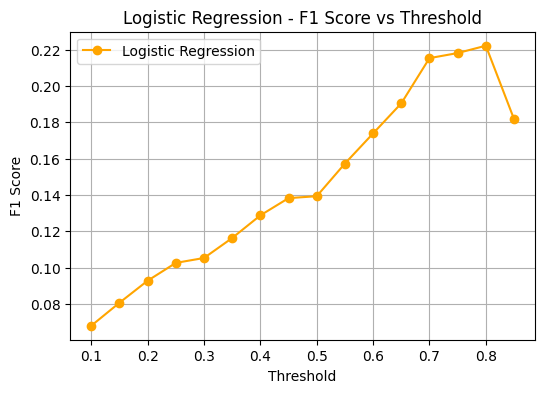

In [ ]:
print("\n📊 Evaluating Logistic Regression")
evaluate_model(models["logistic_regression"], X_test, y_test);

# ---- LOGISTIC REGRESSION ----
print("\n🔧 Threshold Tuning for Logistic Regression")
y_proba_lr = models["logistic_regression"].predict_proba(X_test)[:, 1]
f1_lr = [f1_score(y_test, (y_proba_lr >= t).astype(int)) for t in thresholds]

for t, f1 in zip(thresholds, f1_lr):
    print(f"Threshold: {t:.2f} - F1 Score: {f1:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_lr, marker='o', color='orange', label='Logistic Regression')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Logistic Regression - F1 Score vs Threshold")
plt.grid(True)
plt.legend()
plt.show()


📊 Evaluating XGBoost

Confusion Matrix:
 [[978   6]
 [ 15   1]]

Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.99      0.99       984
        True       0.14      0.06      0.09        16

    accuracy                           0.98      1000
   macro avg       0.56      0.53      0.54      1000
weighted avg       0.97      0.98      0.97      1000

F1 Score: 0.087
ROC AUC Score: 0.887

🔧 Threshold Tuning for XGBoost
Threshold: 0.10 - F1 Score: 0.250
Threshold: 0.15 - F1 Score: 0.235
Threshold: 0.20 - F1 Score: 0.238
Threshold: 0.25 - F1 Score: 0.256
Threshold: 0.30 - F1 Score: 0.235
Threshold: 0.35 - F1 Score: 0.250
Threshold: 0.40 - F1 Score: 0.138
Threshold: 0.45 - F1 Score: 0.080
Threshold: 0.50 - F1 Score: 0.087
Threshold: 0.55 - F1 Score: 0.095
Threshold: 0.60 - F1 Score: 0.095
Threshold: 0.65 - F1 Score: 0.095
Threshold: 0.70 - F1 Score: 0.100
Threshold: 0.75 - F1 Score: 0.100
Threshold: 0.80 - F1 Score: 0.100
Thre

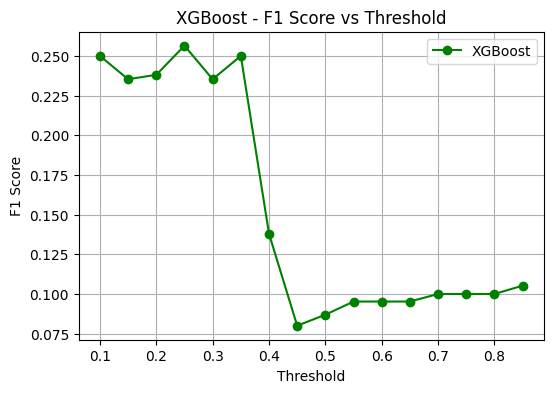

In [ ]:
print("\n📊 Evaluating XGBoost")
evaluate_model(models["xgboost"], X_test, y_test);

print("\n🔧 Threshold Tuning for XGBoost")
y_proba_xgb = models["xgboost"].predict_proba(X_test)[:, 1]
f1_xgb = [f1_score(y_test, (y_proba_xgb >= t).astype(int)) for t in thresholds]

for t, f1 in zip(thresholds, f1_xgb):
    print(f"Threshold: {t:.2f} - F1 Score: {f1:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_xgb, marker='o', color='green', label='XGBoost')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("XGBoost - F1 Score vs Threshold")
plt.grid(True)
plt.legend()
plt.show()



### Interpretation:
Logistic Regression has the highest recall (0.88) for the minority class but terrible precision (0.08) — meaning it's catching many dropouts but wrongly flagging a lot of non-dropouts too.

Random Forest has the best F1 score (0.148) and a solid ROC AUC (0.898), indicating a better balance between precision and recall — especially after you adjusted thresholds (F1 got as high as ~0.254).

XGBoost underperforms on all metrics — not worth pursuing further without major tuning.

In [ ]:
def explain_model(model, X_train, X_test, feature_names):
    import shap

    # Choose appropriate explainer
    if "RandomForest" in str(type(model)) or "XGB" in str(type(model)):
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer(X_test, check_additivity=False)
    else:
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer(X_test)

    shap.summary_plot(shap_values, X_test, feature_names=feature_names)



🔍 SHAP Explanation for Random Forest


 97%|=================== | 1945/2000 [00:27<00:00]       

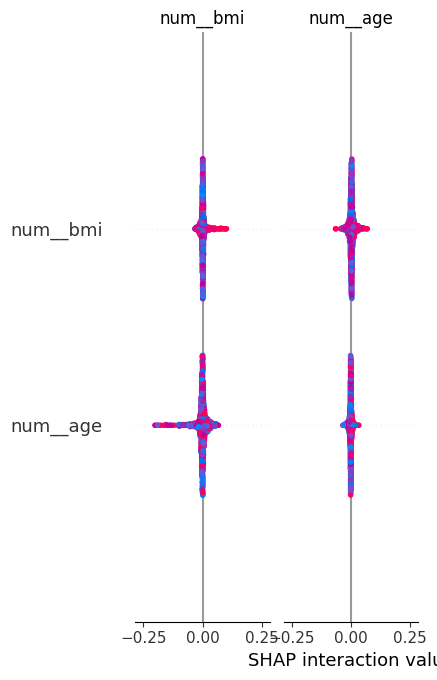


🔍 SHAP Explanation for Logistic Regression


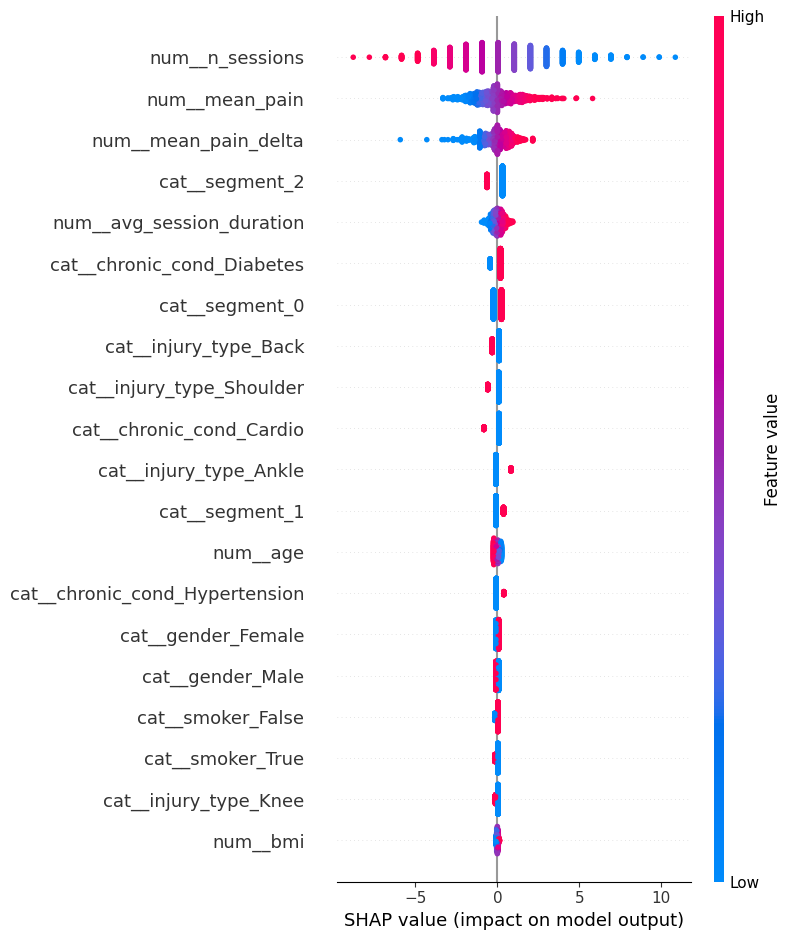


🔍 SHAP Explanation for XGBoost


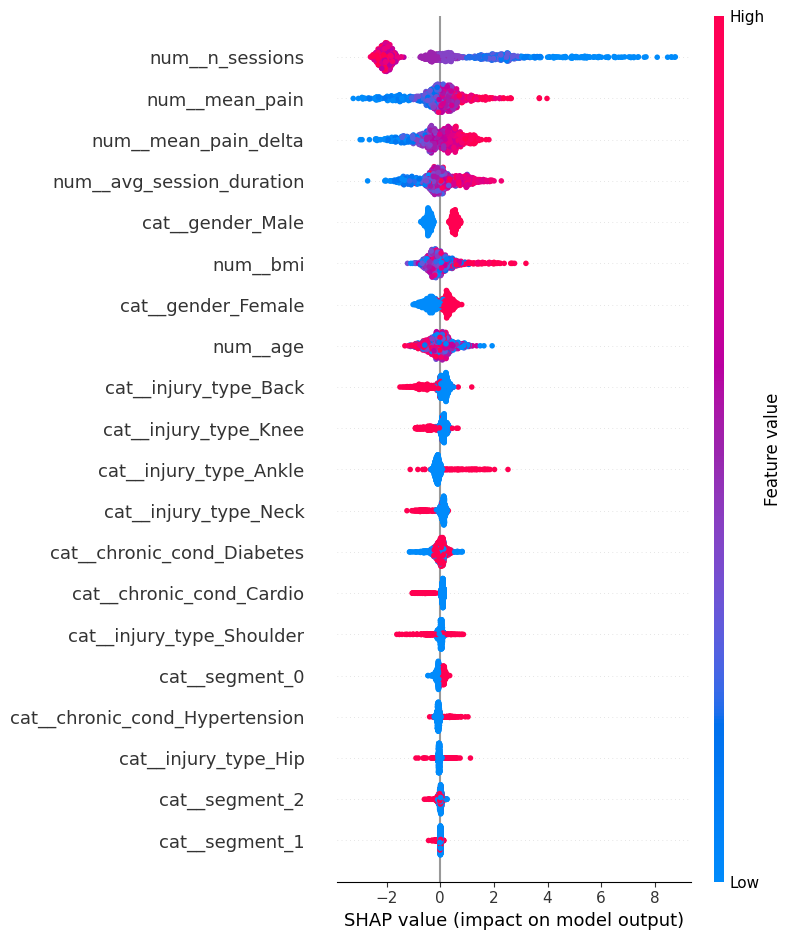

In [ ]:
import shap

# Feature names
feature_names = preproc.get_feature_names_out()

# Random Forest SHAP
print("\n🔍 SHAP Explanation for Random Forest")
explain_model(models["random_forest"], X_train, X_test, feature_names=feature_names)

# Logistic Regression SHAP
print("\n🔍 SHAP Explanation for Logistic Regression")
explain_model(models["logistic_regression"], X_train, X_test, feature_names=feature_names)

# XGBoost SHAP
print("\n🔍 SHAP Explanation for XGBoost")
explain_model(models["xgboost"], X_train, X_test, feature_names=feature_names)


In [ ]:
from prediction import train_model, evaluate_model, explain_model


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

# Store and evaluate it
models["random_forest_tuned"] = best_rf
evaluate_with_threshold(best_rf, X_test, y_test, threshold=0.25);



📊 Evaluation at Threshold = 0.25
Confusion Matrix:
 [[979   5]
 [ 14   2]]

Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.99      0.99       984
        True       0.29      0.12      0.17        16

    accuracy                           0.98      1000
   macro avg       0.64      0.56      0.58      1000
weighted avg       0.97      0.98      0.98      1000

F1 Score: 0.174
ROC AUC Score: 0.880


 97%|=================== | 1944/2000 [00:29<00:00]       

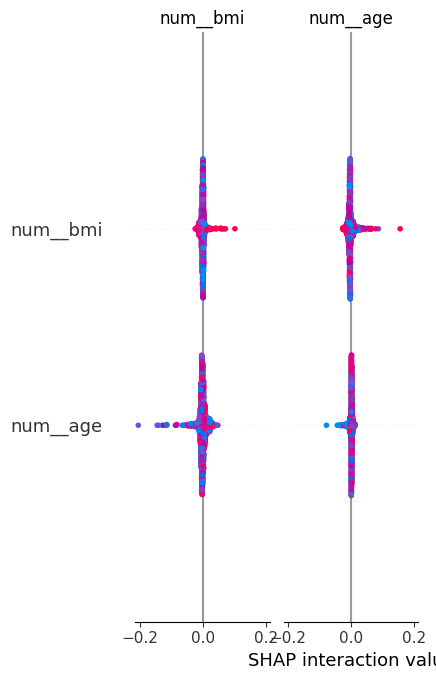

In [ ]:
explainer = shap.Explainer(best_rf, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.summary_plot(shap_values, X_test, feature_names=preproc.get_feature_names_out())
